In [1]:
from keras.applications.mobilenet_v2 import MobileNetV2
from PIL import Image
from keras.preprocessing import image
from keras.applications.mobilenet_v2 import preprocess_input
from keras.models import Model, Sequential, load_model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.regularizers import l1_l2
from keras.optimizers import Adam
from keras.callbacks import Callback, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn import preprocessing as pp
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from keras.layers.normalization import BatchNormalization
import numpy as np
import os
import tensorflow as tf
# import tensorflow.compat.v1 as tf
# tf.disable_v2_behavior() 
import argparse
from sklearn.utils import class_weight

In [2]:
# WATCH OUT!
# dataset split - one time job

data = []
labels = []
to_idx = dict()
to_label = dict()

train_folder = './dataset'
count = 0
for root, dirs, files in os.walk(train_folder):
    for dir in dirs:
        dir_path = os.path.join(root, dir)
        to_idx[dir] = count
        to_label[count] = dir
        # print (dir_path)
        for root2, dir2, files2 in os.walk(dir_path):
            for file in files2:
                img_path = os.path.join(root2, file)
                img = Image.open(img_path)

                if img.mode != 'RGB':
                    img = img.convert('RGB')

                img = np.asarray(img)
                
                data.append(img)
                labels.append(count)

        count += 1

data = np.asarray(data)
labels = np.asarray(labels)

data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.1)

# data_train, data_validation, labels_train, labels_validation = train_test_split(data_train_i, labels_train_i, test_size=0.2)

print (data.shape)
print (labels.shape)

print (data_test.shape)
print (labels_test.shape)

# print (data_validation.shape)
# print (labels_validation.shape)

print (data_train.shape)
print (labels_train.shape)

(4376,)
(4376,)
(438,)
(438,)
(3938,)
(3938,)


In [3]:
def save_dataset_part(dir, data, labels):
    idx = 0
    for img_data in data:
        save_dir = os.path.join(dir, to_label[labels[idx]])

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        image_name = "%d_%d.jpg" % (idx + 1, labels[idx])

        save_image_path = os.path.join(save_dir, image_name)
        image.save_img(save_image_path, img_data)

        # print (save_image_path)
        idx += 1
    print (idx)

# WATCH OUT!
save_dataset_part('./splitted_dataset_90_0_10/train', data_train, labels_train)
save_dataset_part('./splitted_dataset_90_0_10/test', data_test, labels_test)
# save_dataset_part('./splitted_dataset_90_0_10/validation', data_validation, labels_validation)

3938
438


In [2]:
base_model = MobileNetV2(weights = 'imagenet', include_top=False)
x = base_model.output

x = GlobalAveragePooling2D()(x)

model = Model(inputs=base_model.input, outputs=x)

In [4]:
def load_splitted_dataset_part(input_dir, loadedFromCsv):
    if loadedFromCsv:
        return []
    
    print ('Loading images from dir', input_dir)
    global to_idx
    global to_label

    to_idx = dict()
    to_label = dict()
    
    datas = []
    count = 0

    for root, dirs, files in os.walk(input_dir):
        for dir in dirs:
            dir_path = os.path.join(root, dir)
            data = []
            to_idx[dir] = count
            to_label[count] = dir
            for root2, dir2, files2 in os.walk(dir_path):
                for file in files2:
                    img_path = os.path.join(root2, file)
                    img = image.load_img(img_path, target_size=(224, 224))
                    data.append(img)

            datas.append(data)
            print ('Label', count, len(datas[count]))
            count += 1

    return np.asarray(datas)

dataset_dir = './augmented_8_splitted_dataset'
train_data = load_splitted_dataset_part(dataset_dir + '/train', loadedFromCsv = True)
validation_data = load_splitted_dataset_part(dataset_dir + '/validation', loadedFromCsv = True, )
test_data = load_splitted_dataset_part(dataset_dir + '/test', loadedFromCsv = True, )

In [5]:
def load_splitted_info(part, datas, fromCSV = True):
    if fromCSV:
        print ('Importing %s data from .csv files!' % (part))
        
        data = np.loadtxt('%s_data_mobilenet_augmented_8_dataset.csv' % (part), delimiter=',')
        labels = np.loadtxt('%s_labels_mobilenet_augmented_8_dataset.csv' % (part), delimiter=',')
        
        print ('Data imported!')
    else:
        tot = 0
        cnt = 0
        data = []
        labels = []
        for idx in range(len(datas)):
            tot += len(datas[idx])

        for idx in range(len(datas)):
            for img in datas[idx]:
                img_arr = image.img_to_array(img)
                img_arr = np.expand_dims(img_arr, axis = 0)
                img_arr = preprocess_input(img_arr)

                features = model.predict(img_arr)
                features = np.squeeze(features)
                
                data.append(features)
                labels.append(idx)

                cnt += 1
                clear_output(wait=True)
                print ('Processed %d images - %.2f%%' % (cnt, (100.00000 * cnt / tot)))

        data = np.asarray(data)
        labels = np.asarray(labels) 
        
        np.savetxt('%s_data_mobilenet_augmented_8_dataset.csv' % (part), data, delimiter=',')
        np.savetxt('%s_labels_mobilenet_augmented_8_dataset.csv' % (part), labels, delimiter=',')

    print (data.shape, labels.shape)

    return data, labels

train_data, train_labels = load_splitted_info('train', train_data, fromCSV=True)
validation_data, validation_labels = load_splitted_info('validation', validation_data, fromCSV=True)
test_data, test_labels = load_splitted_info('test', test_data, fromCSV=True)

Importing train data from .csv files!
Data imported!
(27872, 1280) (27872,)
Importing validation data from .csv files!
Data imported!
(6968, 1280) (6968,)
Importing test data from .csv files!
Data imported!
(3872, 1280) (3872,)


In [50]:
# cnn = Sequential()
# cnn.add(Dropout(0.7, input_shape=(1280,)))

# xavier_initializer = tf.initializers.glorot_normal()

# class_weights = class_weight.compute_class_weight('balanced',
#                                                  np.unique(train_labels),
#                                                  train_labels)

# class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

# weights_regularizer = l1_l2(0.00001, 0.0001)

# # add model layers
# cnn.add(Dense(
#     units=500,
#     activation='relu',
#     kernel_initializer=xavier_initializer,
#     kernel_regularizer=weights_regularizer
# ))

# cnn.add(Dense(
#     units=17,
#     activation='softmax',
#     kernel_initializer=xavier_initializer,
#     kernel_regularizer=weights_regularizer
# ))

# # build optimizer
# optimizer = Adam(learning_rate=0.001)

# #compile model using accuracy to measure model performance
# cnn.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # reduce learning rate if loss is "plateau"-ing
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001, verbose=1)

# # train the model
# history = cnn.fit(
#     x = train_data,
#     y = train_labels,
#     validation_data=(validation_data, validation_labels),
#     epochs=50,
#     batch_size=128,
#     class_weight=class_weights_dict,
#     callbacks=[reduce_lr]
# )

cnn = Sequential()
cnn.add(Dropout(0.5, input_shape=(1280,)))

# xavier_initializer = tf.initializers.glorot_normal()

class_weights = class_weight.compute_class_weight('balanced',
                                                 np.unique(train_labels),
                                                 train_labels)

class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

weights_regularizer = l1_l2(0.00001, 0.0001)

# add model layers
cnn.add(Dense(
    units=350,
    activation='relu',
    # kernel_initializer=xavier_initializer,
    # kernel_regularizer=weights_regularizer
))

cnn.add(BatchNormalization())
cnn.add(Dropout(0.5))

cnn.add(Dense(
    units=17,
    activation='softmax',
    # kernel_initializer=xavier_initializer,
    # kernel_regularizer=weights_regularizer
))

# build optimizer
optimizer = Adam(learning_rate=0.002)

#compile model using accuracy to measure model performance
cnn.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# reduce learning rate if loss is "plateau"-ing
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001, verbose=1)

# train the model
history = cnn.fit(
    x = train_data,
    y = train_labels,
    validation_data=(validation_data, validation_labels),
    epochs=70,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[reduce_lr]
)

Epoch 1/70
436/436 [==============================] - 2s 4ms/step - loss: 1.6411 - accuracy: 0.5052 - val_loss: 0.9049 - val_accuracy: 0.7107
Epoch 2/70
436/436 [==============================] - 2s 3ms/step - loss: 0.9635 - accuracy: 0.6655 - val_loss: 0.8856 - val_accuracy: 0.7108
Epoch 3/70
436/436 [==============================] - 1s 3ms/step - loss: 0.8972 - accuracy: 0.6862 - val_loss: 0.8943 - val_accuracy: 0.7032
Epoch 4/70
436/436 [==============================] - 2s 3ms/step - loss: 0.8440 - accuracy: 0.6991 - val_loss: 0.8294 - val_accuracy: 0.7283
Epoch 5/70
436/436 [==============================] - 2s 4ms/step - loss: 0.8165 - accuracy: 0.7118 - val_loss: 0.8217 - val_accuracy: 0.7356
Epoch 6/70
436/436 [==============================] - 2s 3ms/step - loss: 0.8021 - accuracy: 0.7124 - val_loss: 0.8000 - val_accuracy: 0.7371
Epoch 7/70
436/436 [==============================] - 2s 3ms/step - loss: 0.7711 - accuracy: 0.7217 - val_loss: 0.8006 - val_accuracy: 0.7359
Epoch 

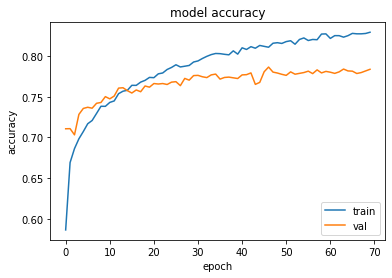

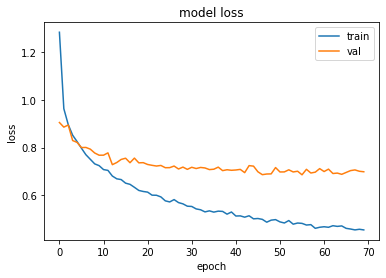

In [57]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

In [52]:
predictions = cnn.predict(test_data)
predicted_labels = np.argmax(predictions, axis = 1)

print ('Accuracy:', metrics.accuracy_score(test_labels, predicted_labels))
print ('Precision:', metrics.precision_score(test_labels, predicted_labels, average='macro'))
print ('Recall:', metrics.recall_score(test_labels, predicted_labels,  average='macro'))

Accuracy: 0.7931301652892562
Precision: 0.7981156759393848
Recall: 0.8051237325147615


In [40]:
model.save('model_mobilenet_augmented_4.h5')
cnn.save('cnn_augmented_4.h5')

cnn.save_weights('weights_cnn_augmented_4.h5')

In [53]:
# train model with existing weights
# cnn.load_weights('weights_cnn_augmented_4.h5')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00000001, verbose=1)
history2 = cnn.fit(train_data, train_labels, validation_data=(validation_data, validation_labels), epochs=130, batch_size=64, callbacks=[reduce_lr])

Epoch 1/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4966 - accuracy: 0.8279 - val_loss: 0.6885 - val_accuracy: 0.7847
Epoch 2/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4718 - accuracy: 0.8382 - val_loss: 0.6756 - val_accuracy: 0.7879
Epoch 3/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4864 - accuracy: 0.8316 - val_loss: 0.6740 - val_accuracy: 0.7892
Epoch 4/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4699 - accuracy: 0.8373 - val_loss: 0.6664 - val_accuracy: 0.7879
Epoch 5/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4726 - accuracy: 0.8379 - val_loss: 0.6783 - val_accuracy: 0.7867
Epoch 6/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4706 - accuracy: 0.8395 - val_loss: 0.6697 - val_accuracy: 0.7956
Epoch 7/130
436/436 [==============================] - 2s 4ms/step - loss: 0.4676 - accuracy: 0.8383 - val_loss: 0.6753 - val_accuracy: 0.7880

In [67]:
cnn.save_weights('weights_best_cnn_augmented_4_after_170ep.h5')

In [54]:
predictions = cnn.predict(test_data)
predicted_labels = np.argmax(predictions, axis = 1)

print ('Accuracy:', metrics.accuracy_score(test_labels, predicted_labels))
print ('Precision:', metrics.precision_score(test_labels, predicted_labels, average='macro'))
print ('Recall:', metrics.recall_score(test_labels, predicted_labels,  average='macro'))

Accuracy: 0.8003615702479339
Precision: 0.8176099813515395
Recall: 0.802184046526619


In [55]:
print (classification_report(test_labels, predicted_labels))

              precision    recall  f1-score   support

         0.0       0.98      0.88      0.92        96
         1.0       0.72      0.71      0.71       224
         2.0       0.96      1.00      0.98       208
         3.0       0.74      0.73      0.73       376
         4.0       0.66      0.83      0.74       328
         5.0       0.82      0.82      0.82       312
         6.0       0.77      0.62      0.69       136
         7.0       0.79      0.71      0.75       152
         8.0       0.77      0.69      0.73       232
         9.0       0.87      0.92      0.90       264
        10.0       0.74      0.80      0.77       272
        11.0       0.88      0.93      0.90       120
        12.0       0.86      0.78      0.81       240
        13.0       0.79      0.80      0.79       264
        14.0       0.84      0.69      0.76       208
        15.0       0.73      0.77      0.75       224
        16.0       0.99      0.98      0.98       216

    accuracy              

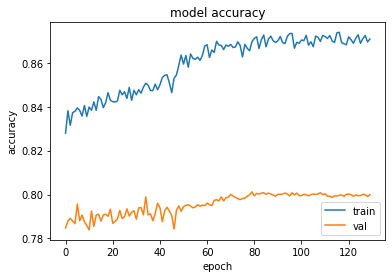

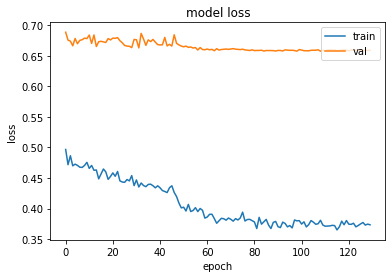

In [56]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.show()

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

In [125]:
# train model with existing weights
# cnn.load_weights('weights_cnn_augmented_4.h5')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001, verbose=1)
history2 = cnn.fit(train_data, train_labels, validation_data=(validation_data, validation_labels), epochs=50, batch_size=128, callbacks=[reduce_lr])

Epoch 1/50
218/218 [==============================] - 6s 26ms/step - loss: 0.4752 - accuracy: 0.9285 - val_loss: 0.9280 - val_accuracy: 0.7972
Epoch 2/50
218/218 [==============================] - 6s 25ms/step - loss: 0.4704 - accuracy: 0.9300 - val_loss: 0.9295 - val_accuracy: 0.7985
Epoch 3/50
218/218 [==============================] - 6s 25ms/step - loss: 0.4714 - accuracy: 0.9295 - val_loss: 0.9269 - val_accuracy: 0.7958
Epoch 4/50
218/218 [==============================] - 6s 25ms/step - loss: 0.4669 - accuracy: 0.9310 - val_loss: 0.9218 - val_accuracy: 0.8011
Epoch 5/50
218/218 [==============================] - 6s 25ms/step - loss: 0.4663 - accuracy: 0.9314 - val_loss: 0.9203 - val_accuracy: 0.8007
Epoch 6/50
218/218 [==============================] - 6s 25ms/step - loss: 0.4616 - accuracy: 0.9338 - val_loss: 0.9186 - val_accuracy: 0.8001
Epoch 7/50
218/218 [==============================] - 6s 26ms/step - loss: 0.4666 - accuracy: 0.9315 - val_loss: 0.9210 - val_accuracy: 0.7997

In [126]:
predictions = cnn.predict(test_data)
predicted_labels = np.argmax(predictions, axis = 1)

print ('Accuracy:', metrics.accuracy_score(test_labels, predicted_labels))
print ('Precision:', metrics.precision_score(test_labels, predicted_labels, average='macro'))
print ('Recall:', metrics.recall_score(test_labels, predicted_labels,  average='macro'))

Accuracy: 0.8140495867768595
Precision: 0.8274400490452054
Recall: 0.8177139238754892
